In [1]:
# -----------------------------
# Imports & Setup
# -----------------------------
import sys
from pathlib import Path
import logging

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import joblib

# Optional ensemble models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# -----------------------------
# Project Path Setup
# -----------------------------
project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root))

# -----------------------------
# Custom Modules
# -----------------------------
from src.data.loader import CreditCardDataLoader
from src.modeling import ModelingPipeline, PipelineConfig
from src.utils.io_utils import save_dataframe

# -----------------------------
# Pandas & Seaborn Settings
# -----------------------------
pd.set_option("display.max_columns", 50)
sns.set(style="whitegrid")

# -----------------------------
# Logging Setup
# -----------------------------
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("Modeling_Fraud")


In [2]:
# -----------------------------
# Load Processed Feature-Engineered Data
# -----------------------------
credit_loader = CreditCardDataLoader("../data/processed/credit_data_cleaned.csv")
credit_df = credit_loader.load()

logger.info(f"Credit data shape: {credit_df.shape}")
logger.info(f"Credit data columns: {credit_df.columns}")

credit_df.head()


2026-02-15 09:22:36,916 [INFO] Loaded file: ..\data\processed\credit_data_cleaned.csv with shape (283726, 31)
2026-02-15 09:22:36,923 [INFO] Credit card dataset validation complete
2026-02-15 09:22:36,923 [INFO] Credit data shape: (283726, 31)
2026-02-15 09:22:36,923 [INFO] Credit data columns: Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# -----------------------------
# Features & Target
# -----------------------------
NUMERIC_FEATURES = [col for col in credit_df.columns if col != 'Class']  # V1-V28 + Time + Amount
CATEGORICAL_FEATURES = [] 
TARGET = 'Class'

config = PipelineConfig(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    target_col=TARGET,
    use_smote=True
)

pipeline = ModelingPipeline(
    df=credit_df,
    config=config
)


2026-02-15 09:22:40,354 [INFO] Initialized pipeline with 283726 rows


2026-02-15 09:22:44,162 [INFO] Step 1: Preparing data...
2026-02-15 09:22:44,449 [INFO] Training shape: (226980, 30), Test shape: (56746, 30)


Training set: 226,980 samples
Test set: 56,746 samples

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


2026-02-15 09:22:44,666 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-15 09:22:44,747 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-15 09:22:44,830 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-15 09:22:44,855 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


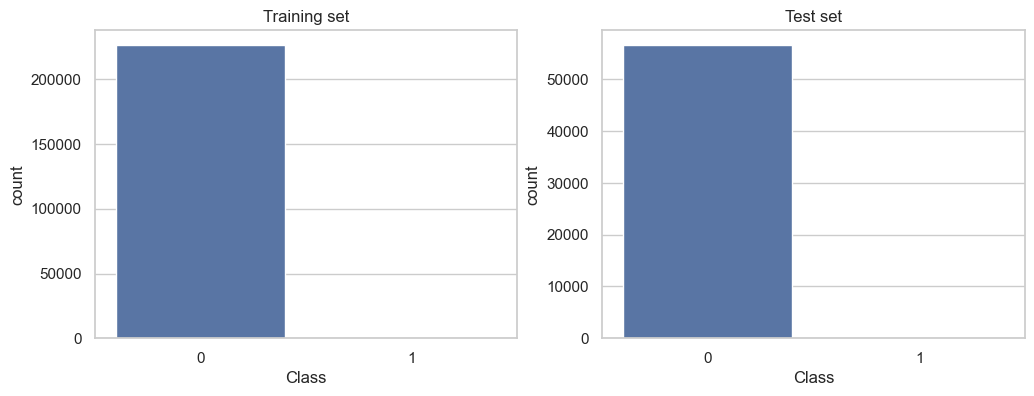

In [4]:
# -----------------------------
# Split, Scale & Encode
# -----------------------------
X_train, X_test, y_train, y_test = pipeline.prepare_data()

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

# Plot class distribution
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.countplot(x=y_train)
plt.title("Training set")
plt.subplot(1,2,2)
sns.countplot(x=y_test)
plt.title("Test set")
plt.show()


In [5]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    cm_sum = cm.sum()
    cm_percent = cm / cm_sum * 100
    labels = np.array([["{} ({:.1f}%)".format(val, pct) 
                        for val, pct in zip(row_val, row_pct)]
                       for row_val, row_pct in zip(cm, cm_percent)])
    
    fig, ax = plt.subplots(figsize=(6,6))
    cax = ax.matshow(cm, cmap='Blues')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i,j] > cm.max()/2 else "black"
            ax.text(j, i, labels[i,j], va='center', ha='center', color=color, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks(range(cm.shape[0]))
    ax.set_yticks(range(cm.shape[1]))
    plt.title(title, pad=20)
    plt.show()

def plot_precision_recall_curve_model(model, X_test, y_test, title="Precision-Recall Curve"):
    y_prob = model.predict_proba(X_test)[:,1]
    PrecisionRecallDisplay.from_predictions(y_test, y_prob)
    plt.title(title)
    plt.show()

def plot_roc_curve_model(model, X_test, y_test, title="ROC Curve"):
    y_prob = model.predict_proba(X_test)[:,1]
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(title)
    plt.show()

def plot_model_comparison_barplot(models, model_names, X_test, y_test):
    """
    Plots a barplot comparing Precision, Recall, and F1-score for all models on class 1 (fraud)
    """
    metrics_summary = []

    for model, name in zip(models, model_names):
        y_pred = model.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True)
        metrics_summary.append({
            "Model": name,
            "Precision": report['1']['precision'],
            "Recall": report['1']['recall'],
            "F1-Score": report['1']['f1-score']
        })

    metrics_df = pd.DataFrame(metrics_summary)
    metrics_df = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

    plt.figure(figsize=(10,6))
    sns.barplot(x="Model", y="Score", hue="Metric", data=metrics_df)
    plt.title("Model Comparison — Key Metrics (Class 1: Fraud)")
    plt.ylim(0,1)
    plt.legend(loc="lower right")
    plt.show()


2026-02-15 09:22:58,051 [INFO] Training Logistic Regression...


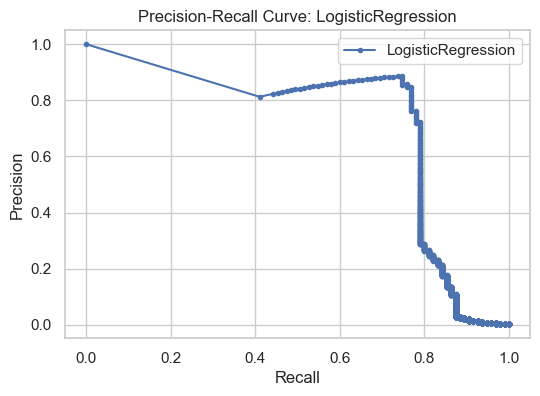

2026-02-15 09:23:35,142 [INFO] Running Stratified 5-Fold CV...
2026-02-15 09:23:42,979 [INFO] Logistic Regression best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
2026-02-15 09:23:42,991 [INFO] Evaluating Logistic Regression...


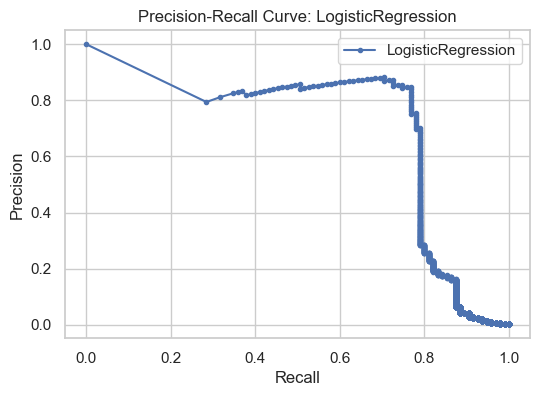

AUC_PR: 0.672
F1: 0.102
Precision: 0.054
Recall: 0.884


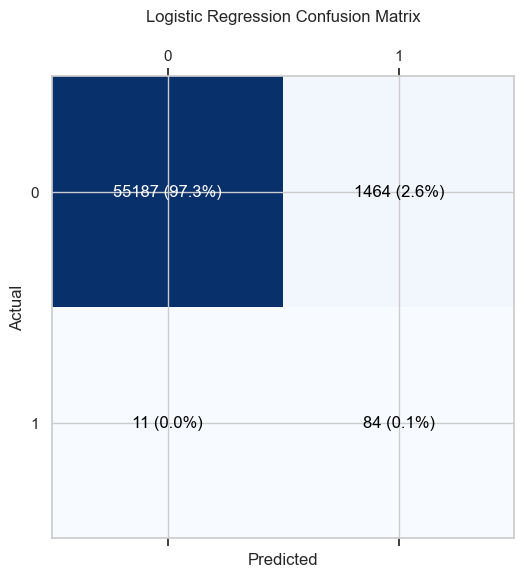

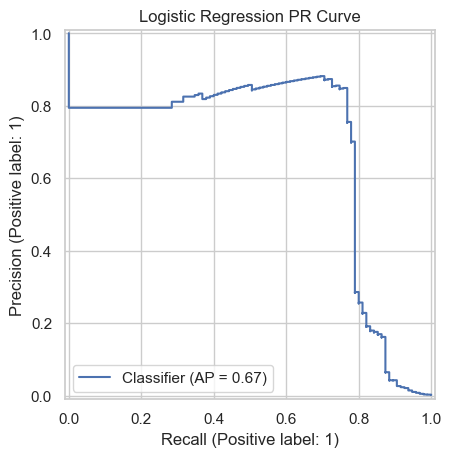

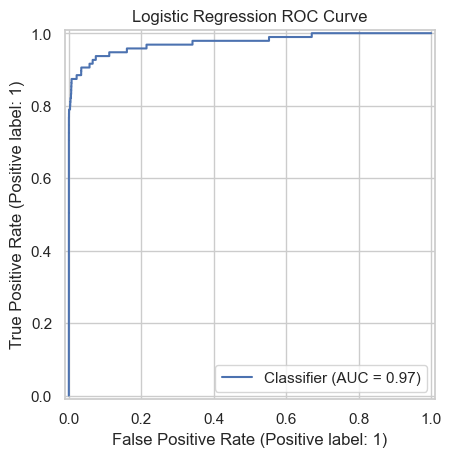

In [6]:
logger.info("Training Logistic Regression...")
lr_model = pipeline.tune_and_train_logistic_regression()

logger.info("Evaluating Logistic Regression...")
metrics = pipeline.evaluate(lr_model)
for k,v in metrics.items():
    if k != "ConfusionMatrix":
        print(f"{k}: {v:.3f}")

plot_confusion_matrix(y_test, lr_model.predict(X_test), title="Logistic Regression Confusion Matrix")
plot_precision_recall_curve_model(lr_model, X_test, y_test, title="Logistic Regression PR Curve")
plot_roc_curve_model(lr_model, X_test, y_test, title="Logistic Regression ROC Curve")


2026-02-15 09:24:16,427 [INFO] Training Random Forest...


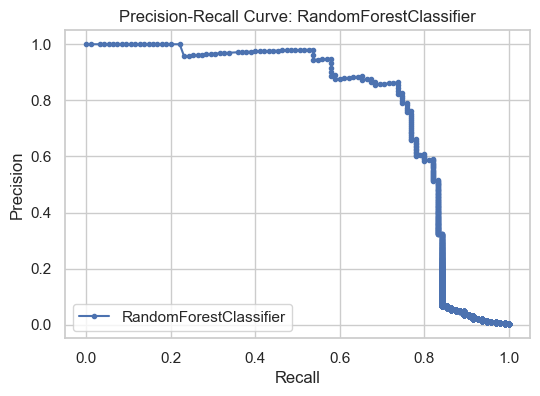

2026-02-15 09:25:21,541 [INFO] Running Stratified 5-Fold CV...
2026-02-15 09:31:16,427 [INFO] Evaluating Random Forest...


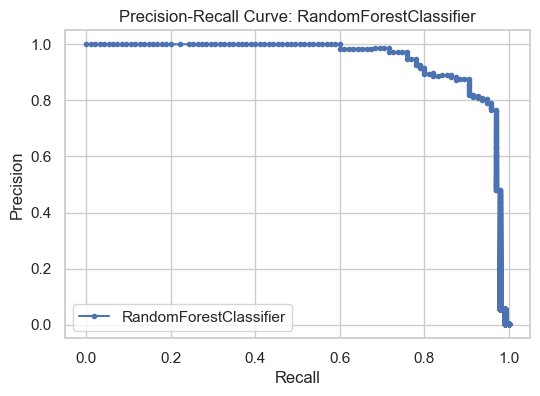

AUC_PR: 0.944
F1: 0.646
Precision: 0.484
Recall: 0.968


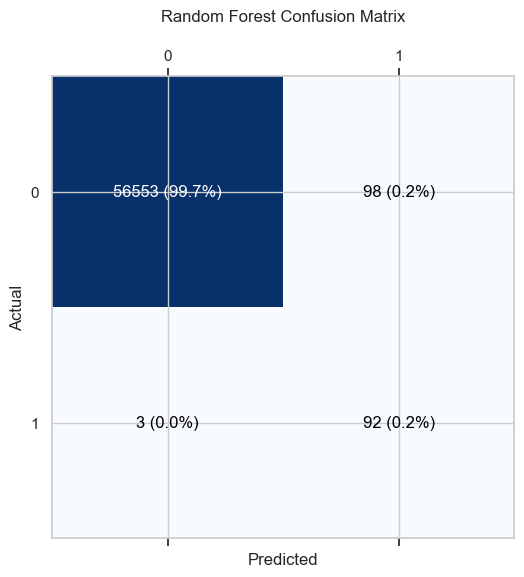

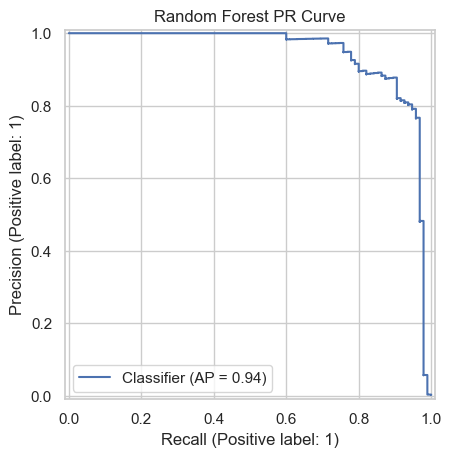

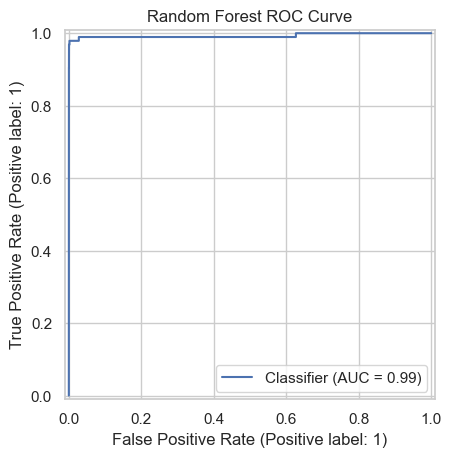

In [7]:
logger.info("Training Random Forest...")
rf_model = pipeline.train_random_forest()

logger.info("Evaluating Random Forest...")
metrics = pipeline.evaluate(rf_model)
for k,v in metrics.items():
    if k != "ConfusionMatrix":
        print(f"{k}: {v:.3f}")

plot_confusion_matrix(y_test, rf_model.predict(X_test), title="Random Forest Confusion Matrix")
plot_precision_recall_curve_model(rf_model, X_test, y_test, title="Random Forest PR Curve")
plot_roc_curve_model(rf_model, X_test, y_test, title="Random Forest ROC Curve")


2026-02-15 09:31:54,410 [INFO] Training XGBoost using ModelingPipeline...
2026-02-15 09:31:54,412 [INFO] Step 1: Preparing data...
2026-02-15 09:31:54,674 [INFO] Training shape: (226980, 30), Test shape: (56746, 30)
c:\Users\amare\Documents\KAIM\week5-6\financial-fraud-detection\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:31:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


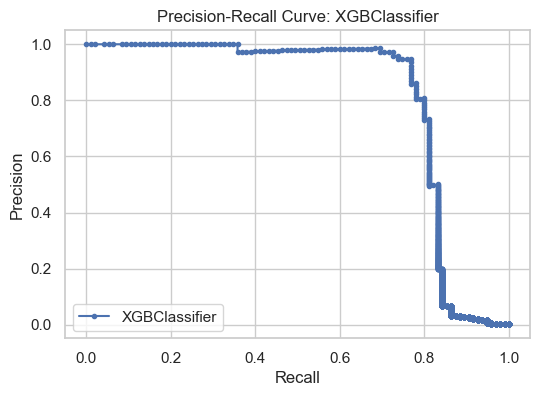

2026-02-15 09:32:00,456 [INFO] Running Stratified 5-Fold CV...
c:\Users\amare\Documents\KAIM\week5-6\financial-fraud-detection\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:32:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\amare\Documents\KAIM\week5-6\financial-fraud-detection\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:32:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\amare\Documents\KAIM\week5-6\financial-fraud-detection\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:32:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\amare\Documents\KAIM\w

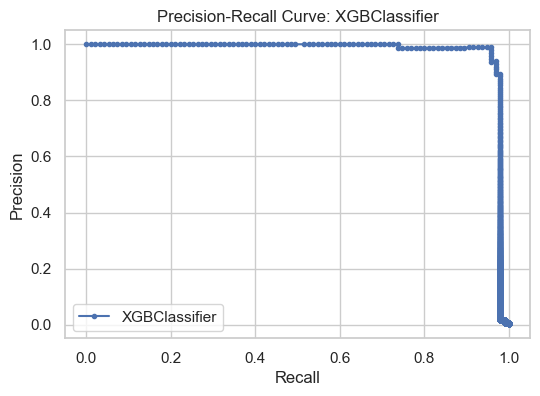

AUC_PR: 0.975
F1: 0.873
Precision: 0.788
Recall: 0.979


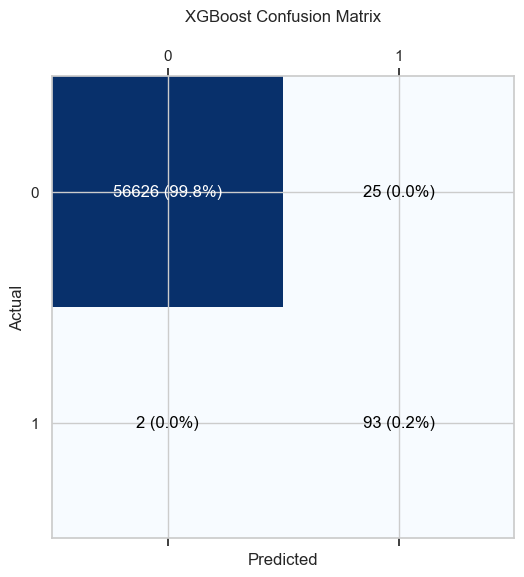

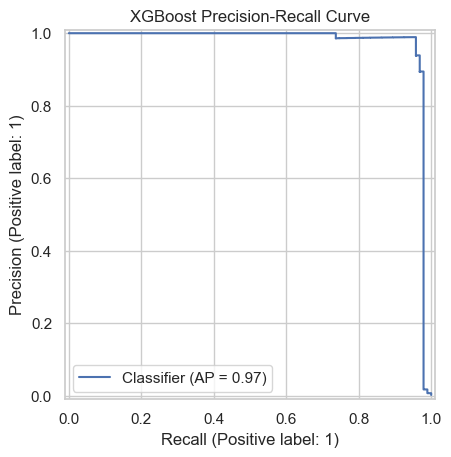

In [8]:


logger.info("Training XGBoost using ModelingPipeline...")

# Ensure data is prepared
pipeline.prepare_data()

# Train XGBoost via pipeline
xgb_model = pipeline.train_xgboost(
    params={
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.1,
        "random_state": 42
    }
)

# Evaluation metrics already computed inside pipeline,
# but we can re-run evaluation explicitly if needed
metrics = pipeline.evaluate(xgb_model)

for k, v in metrics.items():
    if k != "ConfusionMatrix":
        print(f"{k}: {v:.3f}")

# Confusion Matrix
plot_confusion_matrix(
    pipeline.y_test,
    xgb_model.predict(pipeline.X_test),
    title="XGBoost Confusion Matrix"
)

# Precision-Recall Curve
plot_precision_recall_curve_model(
    xgb_model,
    pipeline.X_test,
    pipeline.y_test,
    title="XGBoost Precision-Recall Curve"
)


2026-02-15 09:32:46,037 [INFO] Training LightGBM using ModelingPipeline...
2026-02-15 09:32:46,038 [INFO] Step 1: Preparing data...
2026-02-15 09:32:46,298 [INFO] Training shape: (226980, 30), Test shape: (56746, 30)


[LightGBM] [Info] Number of positive: 226602, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032875 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 453204, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


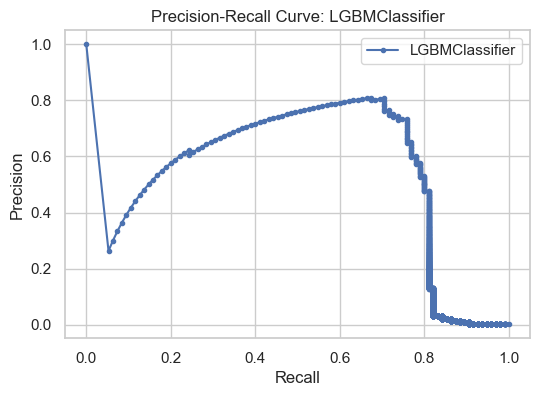

2026-02-15 09:32:51,688 [INFO] Running Stratified 5-Fold CV...


[LightGBM] [Info] Number of positive: 226602, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048959 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 453204, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 226602, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.056382 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 453204, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

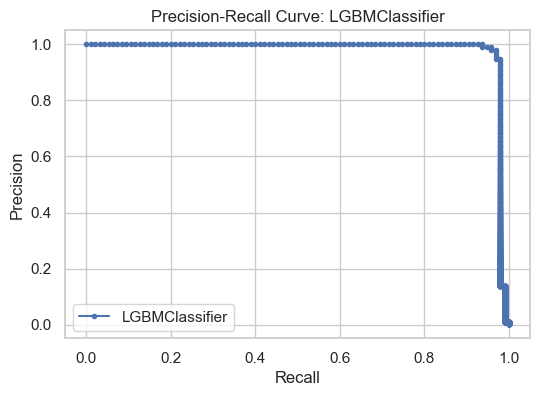

AUC_PR: 0.980
F1: 0.890
Precision: 0.816
Recall: 0.979


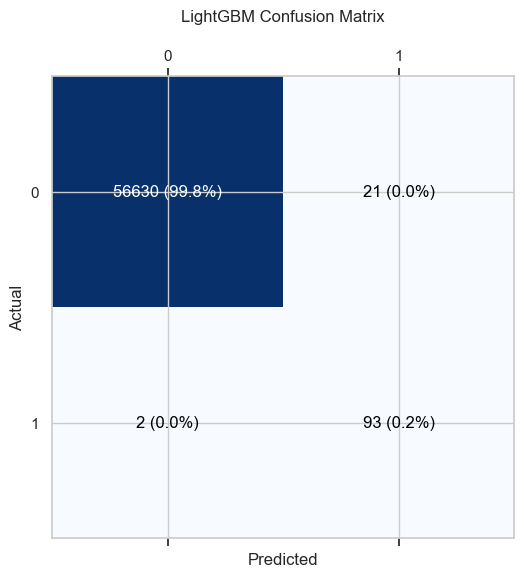

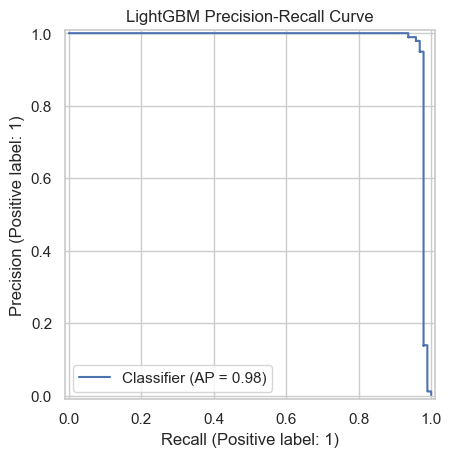

In [9]:
logger.info("Training LightGBM using ModelingPipeline...")

# Ensure data is prepared (remove if already called earlier)
pipeline.prepare_data()

# Train LightGBM via pipeline
lgbm_model = pipeline.train_lightgbm(
    params={
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.1,
        "random_state": 42
    }
)

# Optional: re-evaluate explicitly (already done internally)
metrics = pipeline.evaluate(lgbm_model)

for k, v in metrics.items():
    if k != "ConfusionMatrix":
        print(f"{k}: {v:.3f}")

# Confusion Matrix
plot_confusion_matrix(
    pipeline.y_test,
    lgbm_model.predict(pipeline.X_test),
    title="LightGBM Confusion Matrix"
)

# Precision-Recall Curve
plot_precision_recall_curve_model(
    lgbm_model,
    pipeline.X_test,
    pipeline.y_test,
    title="LightGBM Precision-Recall Curve"
)


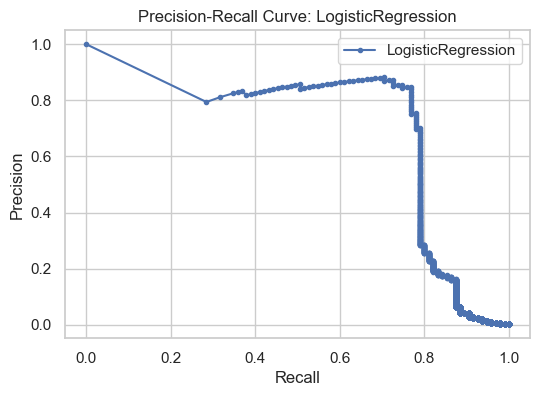

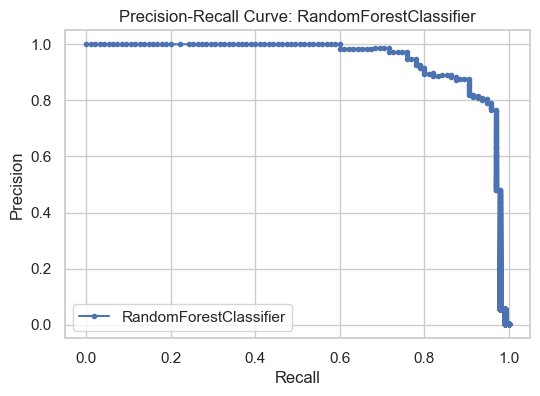

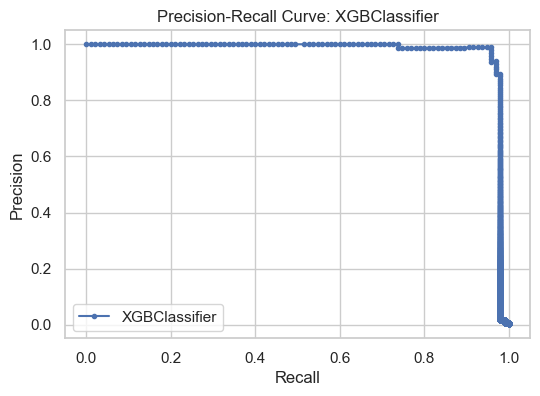

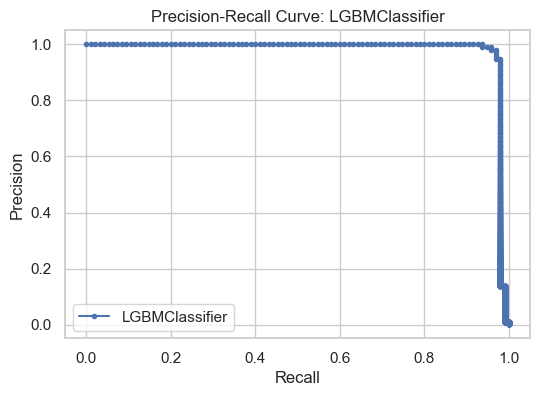

,Model,AUC_PR,F1,Precision,Recall,ConfusionMatrix
0,Logistic Regression,0.672260,0.102252,0.054264,0.884211,"[[55187, 1464], [11, 84]]"
1,Random Forest,0.943840,0.645614,0.484211,0.968421,"[[56553, 98], [3, 92]]"
2,XGBoost,0.974725,0.873239,0.788136,0.978947,"[[56626, 25], [2, 93]]"
3,LightGBM,0.979537,0.889952,0.815789,0.978947,"[[56630, 21], [2, 93]]"


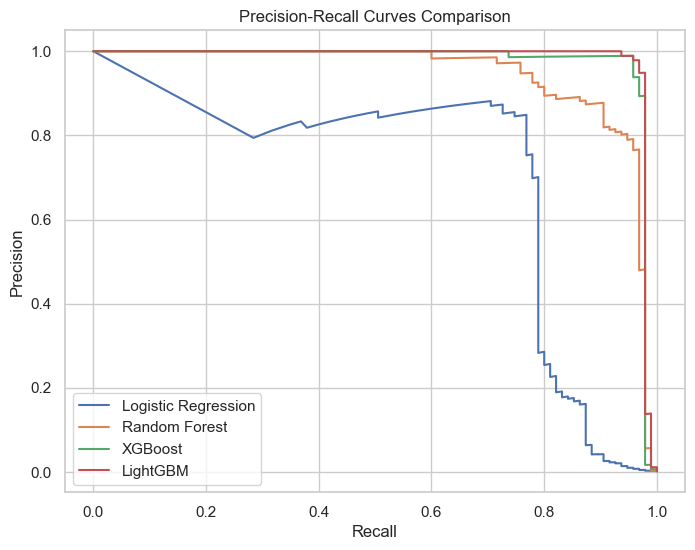

In [10]:
all_models = [lr_model, rf_model, xgb_model, lgbm_model]
all_model_names = ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"]

comparison_list = []
for model, name in zip(all_models, all_model_names):
    metrics = pipeline.evaluate(model)
    comparison_list.append({"Model": name, **metrics})

comparison_df = pd.DataFrame(comparison_list)
display(comparison_df)

# Plot side-by-side PR curves
plt.figure(figsize=(8,6))
for model, name in zip(all_models, all_model_names):
    y_prob = model.predict_proba(X_test)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves Comparison")
plt.legend()
plt.show()



Classification Report — Logistic Regression


,precision,recall,f1-score,support
0,0.999801,0.974158,0.986813,56651.000000
1,0.054264,0.884211,0.102252,95.000000
accuracy,0.974007,0.974007,0.974007,0.974007
macro avg,0.527032,0.929184,0.544532,56746.000000
weighted avg,0.998218,0.974007,0.985332,56746.000000



Classification Report — Random Forest


,precision,recall,f1-score,support
0,0.999947,0.998270,0.999108,56651.00000
1,0.484211,0.968421,0.645614,95.00000
accuracy,0.998220,0.998220,0.998220,0.99822
macro avg,0.742079,0.983346,0.822361,56746.00000
weighted avg,0.999084,0.998220,0.998516,56746.00000



Classification Report — XGBoost


,precision,recall,f1-score,support
0,0.999965,0.999559,0.999762,56651.000000
1,0.788136,0.978947,0.873239,95.000000
accuracy,0.999524,0.999524,0.999524,0.999524
macro avg,0.894050,0.989253,0.936501,56746.000000
weighted avg,0.999610,0.999524,0.999550,56746.000000



Classification Report — LightGBM


,precision,recall,f1-score,support
0,0.999965,0.999629,0.999797,56651.000000
1,0.815789,0.978947,0.889952,95.000000
accuracy,0.999595,0.999595,0.999595,0.999595
macro avg,0.907877,0.989288,0.944875,56746.000000
weighted avg,0.999656,0.999595,0.999613,56746.000000


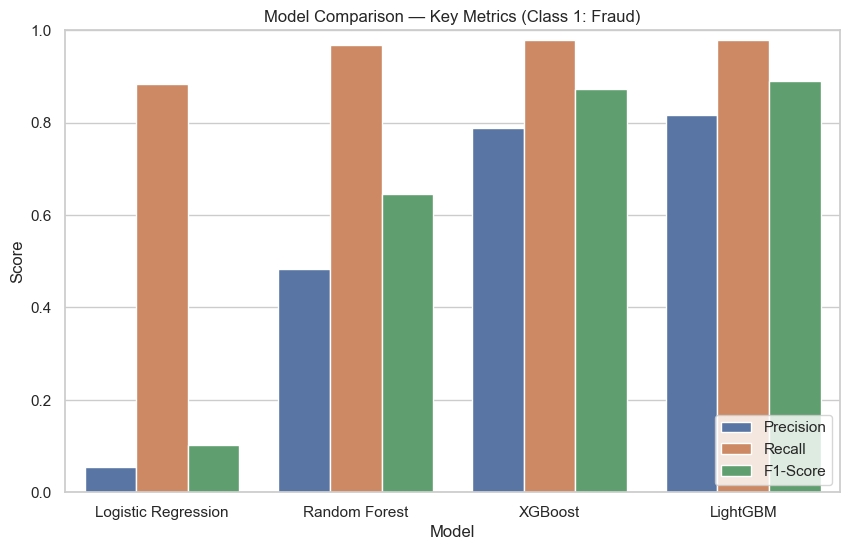

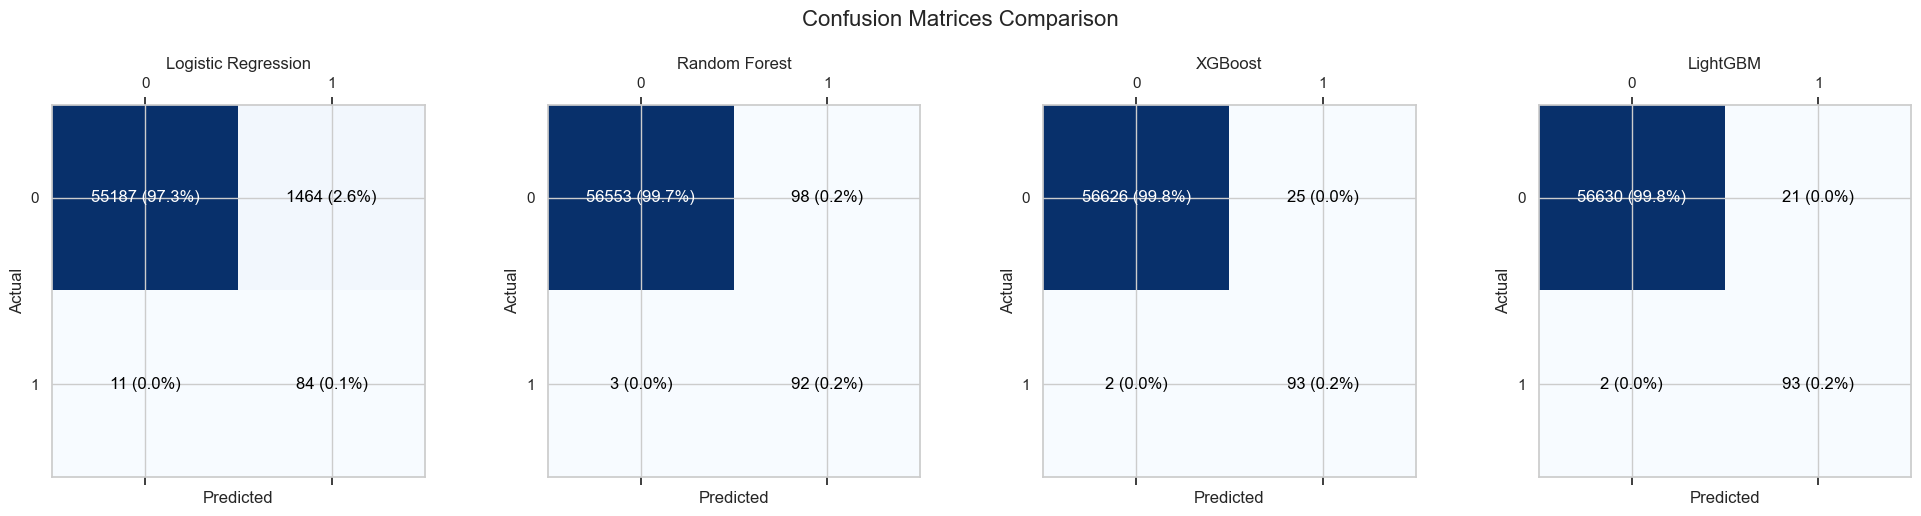

In [11]:
all_models = [lr_model, rf_model, xgb_model, lgbm_model]
all_model_names = ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"]

# Classification reports
all_class_reports = {}
for model, name in zip(all_models, all_model_names):
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    all_class_reports[name] = report
    print(f"\nClassification Report — {name}")
    display(pd.DataFrame(report).transpose())

# Barplot of key metrics
plot_model_comparison_barplot(all_models, all_model_names, X_test, y_test)

# Combined confusion matrices
fig, axes = plt.subplots(1, len(all_models), figsize=(20,5))
for ax, model, name in zip(axes, all_models, all_model_names):
    cm = confusion_matrix(y_test, model.predict(X_test))
    cm_sum = cm.sum()
    cm_percent = cm / cm_sum * 100
    labels = np.array([["{} ({:.1f}%)".format(val, pct) 
                        for val, pct in zip(row_val, row_pct)]
                       for row_val, row_pct in zip(cm, cm_percent)])
    ax.matshow(cm, cmap='Blues')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i,j] > cm.max()/2 else "black"
            ax.text(j, i, labels[i,j], va='center', ha='center', color=color, fontsize=12)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(cm.shape[0]))
    ax.set_yticks(range(cm.shape[1]))
plt.suptitle("Confusion Matrices Comparison", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [12]:
best_model_info, justification = pipeline.select_best_model()
display(best_model_info)
print("\nJustification:", justification)

# Save models and preprocessor
models_dir = Path.cwd().parent / "models"
models_dir.mkdir(exist_ok=True)

best_model_name = best_model_info["Model"]
best_model = {"Logistic Regression": lr_model,
              "Random Forest": rf_model,
              "XGBoost": xgb_model,
              "LightGBM": lgbm_model}[best_model_name]

model_filename = models_dir / f"{best_model_name.replace(' ','_').lower()}_credit_data.joblib"
joblib.dump(best_model, model_filename)
print(f"Saved best model: {model_filename}")

preprocessor_filename = models_dir / "preprocessor_credit_data.joblib"
joblib.dump(pipeline.preprocessor, preprocessor_filename)
print(f"Saved preprocessor: {preprocessor_filename}")


2026-02-15 09:34:10,006 [INFO] Comparing models...
2026-02-15 09:34:10,011 [INFO] XGBoost selected due to highest AUC-PR (0.809) and strong recall, prioritizing undetected fraud reduction while maintaining interpretability.


Model                              XGBoost
AUC_PR                             0.80862
F1                                0.726415
Precision                          0.65812
Recall                            0.810526
ConfusionMatrix    [[56611, 40], [18, 77]]
F1_mean                           0.722116
F1_std                             0.01195
AUC_PR_mean                       0.842352
AUC_PR_std                        0.010593
Name: 0, dtype: object


Justification: XGBoost selected due to highest AUC-PR (0.809) and strong recall, prioritizing undetected fraud reduction while maintaining interpretability.
Saved best model: c:\Users\amare\Documents\KAIM\week5-6\financial-fraud-detection\models\xgboost_credit_data.joblib
Saved preprocessor: c:\Users\amare\Documents\KAIM\week5-6\financial-fraud-detection\models\preprocessor_credit_data.joblib
